# 11 - Prioritization engine (Stage 13)

**Goal.** Build the dispatch engine and benchmark the LightSafe queue against First-In-First-Out (FIFO). All logic is in `src/models/prioritization_engine.py`; this notebook calls it.

**Reading the results.** The impact credited per repair is the Stage 12 `priority_score` (a decision-support index, not a probability; Stage 12's tau_net is not statistically distinguishable from zero and durations are retrospective). So 'cumulative expected crimes prevented' below is cumulative **index points**. The comparison benchmarks the index under this simulation; it does not show that the queue prevents crime.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.models import prioritization_engine as pe
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

## 1. Stage 12 input

In [2]:
scored = pe.load_scored()
print(scored.shape)
print(scored.scored.value_counts().to_dict(), scored.exclusion_reason.value_counts().to_dict())
print(scored.priority_tier.value_counts().to_dict())

(107731, 55)
{True: 103830, False: 3901} {'lookback_not_covered_by_crime_data': 3901}
{'Low': 103799, 'Medium': 28, 'High': 3}


## 2. The two queues
- **FIFO:** `created_date` ascending, ties by `unique_key`.
- **LightSafe Causal:** `priority_score` descending, ties by `created_date` then `unique_key`.
- Unscored outages (no crime coverage for the look-back window) are excluded from both queues; they are not treated as high or low priority.

In [3]:
queue, comparison, info = pe.run(scored, capacity=pe.DEFAULT_CAPACITY)
print(info)
for m in (pe.METHOD_FIFO, pe.METHOD_LIGHTSAFE):
    print(m); print(queue[queue.method == m].head(5)[['queue_rank','repair_day','outage_id','created_date','priority_score','priority_tier']])

{'n_input': 107731, 'n_simulated': 103830, 'n_excluded': 3901, 'exclusion_reasons': {'lookback_not_covered_by_crime_data': 3901}, 'capacity': 20}
FIFO
   queue_rank  repair_day  outage_id        created_date  priority_score priority_tier
0           1           1   45284057 2020-01-01 00:45:00        2.292890           Low
1           2           1   45284935 2020-01-01 06:55:00        0.044206           Low
2           3           1   45287354 2020-01-01 11:03:00        0.074111           Low
3           4           1   45284934 2020-01-01 11:04:00        0.155662           Low
4           5           1   45287019 2020-01-01 11:40:00        0.000000           Low
LightSafe
        queue_rank  repair_day  outage_id        created_date  priority_score priority_tier
103830           1           1   57807769 2023-06-05 17:37:00      100.000000          High
103831           2           1   65567892 2025-07-15 09:19:00       88.530035          High
103832           3           1   57943263

## 3. Repair-capacity simulation (K = 20 per day)
Rank r is repaired on day ceil(r / K). All scored outages are in the backlog at day 0.

In [4]:
print('repairs per day (max):', queue.groupby(['method','repair_day']).size().max(), '| days to clear:', comparison.day.max())
print(queue.groupby('method').repair_day.max())

repairs per day (max): 20 | days to clear: 5192
method
FIFO         5192
LightSafe    5192
Name: repair_day, dtype: int64


## 4. Cumulative expected impact and FIFO vs LightSafe

In [5]:
milestones = [1, 7, 30, 90, 365, 1000, int(comparison.day.max())]
comparison.set_index('day').loc[milestones, ['cumulative_repairs','fifo_cumulative_impact','lightsafe_cumulative_impact','absolute_difference','improvement_pct']].round(2)

,cumulative_repairs,fifo_cumulative_impact,lightsafe_cumulative_impact,absolute_difference,improvement_pct
day,,,,,
1,20,3.22,1208.63,1205.41,37426.60
7,140,30.65,5026.46,4995.80,16298.53
30,600,254.64,13354.37,13099.73,5144.47
90,1800,665.72,24582.97,23917.24,3592.66
365,7300,2713.67,41609.66,38895.99,1433.33
1000,20000,8363.84,50112.64,41748.80,499.16
5192,103830,54346.99,54346.99,0.00,0.00


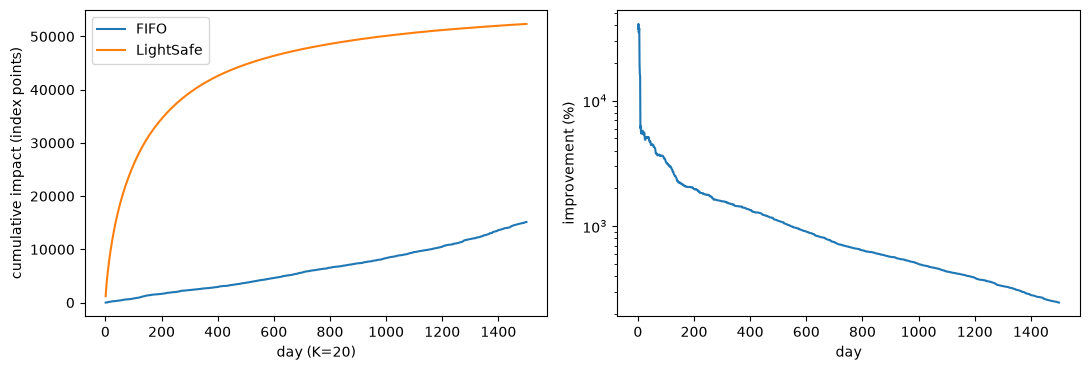

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
c = comparison[comparison.day <= 1500]
ax[0].plot(c.day, c.fifo_cumulative_impact, label='FIFO'); ax[0].plot(c.day, c.lightsafe_cumulative_impact, label='LightSafe')
ax[0].set_xlabel('day (K=20)'); ax[0].set_ylabel('cumulative impact (index points)'); ax[0].legend()
ax[1].plot(c.day, c.improvement_pct); ax[1].set_yscale('log'); ax[1].set_xlabel('day'); ax[1].set_ylabel('improvement (%)')
plt.tight_layout(); plt.show()

In [7]:
T = comparison.fifo_cumulative_impact.iloc[-1]
for share in (0.5, 0.9):
    f = int((comparison.fifo_cumulative_impact >= share*T).idxmax() + 1); l = int((comparison.lightsafe_cumulative_impact >= share*T).idxmax() + 1)
    print(f'{int(share*100)}% of total impact reached on day: FIFO {f}, LightSafe {l}')
print('final totals equal:', np.isclose(comparison.fifo_cumulative_impact.iloc[-1], comparison.lightsafe_cumulative_impact.iloc[-1]))

50% of total impact reached on day: FIFO 2495, LightSafe 112
90% of total impact reached on day: FIFO 4511, LightSafe 836
final totals equal: True


## 5. Saved outputs match the engine

In [8]:
q = pd.read_csv(pe.OUTPUT_DIR / pe.QUEUE_FILENAME); c = pd.read_csv(pe.OUTPUT_DIR / pe.COMPARISON_FILENAME)
print(q.shape, c.shape, '| comparison matches:', np.allclose(c.lightsafe_cumulative_impact, comparison.lightsafe_cumulative_impact, rtol=1e-8))

(207660, 12) (5192, 8) | comparison matches: True


## 6. Interpretation and limitations
- LightSafe accumulates index points far faster (for example 1,208 vs 3 after day 1) because the score is extremely right-skewed: a few high-scoring outages dominate. The large percentages (hundreds to tens of thousands of percent early) are mostly this skew, and they are by construction: the queue maximises the same index it is measured on.
- Both queues repair the same outages, so the final totals are equal and the improvement tends to 0% by the last day.
- Not a proof of crime prevention: tau_net is a constant not distinguishable from zero, duration is observed post hoc, and the scores are retrospective. The simulation is a static backlog (created_date does not delay availability) with a fixed K.